In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('crime_rate_safety_analysis.csv')
df

,incident_id,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,CRM0000001,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,...,2,46,No,No,No,No Coverage,Poorly Lit,3,62.8,No
1,CRM0000002,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,...,2,115,No,Yes,No,Partial Coverage,Partially Lit,1,50.7,No
2,CRM0000003,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,...,1,56,Yes,No,No,No Coverage,Well Lit,0,61.3,Yes
3,CRM0000004,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,...,4,44,Yes,Yes,No,Partial Coverage,Partially Lit,6,51.7,Yes
4,CRM0000005,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,...,5,111,No,Unknown,Yes,Partial Coverage,Partially Lit,2,52.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CRM0009996,2024,11,Thursday,Winter,Morning (6am-12pm),Turkey,Suburban,327,Burglary,...,3,27,No,Yes,No,Partial Coverage,Well Lit,5,75.6,No
9996,CRM0009997,2024,4,Tuesday,Spring,Afternoon (12pm-6pm),Germany,Urban,1136,Burglary,...,5,41,No,No,No,Partial Coverage,Partially Lit,0,61.4,No
9997,CRM0009998,2024,11,Tuesday,Summer,Evening (6pm-10pm),France,Suburban,436,Assault,...,3,30,Unknown,No,Yes,Partial Coverage,Poorly Lit,1,65.1,Yes
9998,CRM0009999,2022,1,Friday,Summer,Evening (6pm-10pm),USA,Rural,169,Cybercrime,...,1,27,Unknown,No,No,Partial Coverage,Well Lit,2,77.5,No


In [4]:
df.head()


,incident_id,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,CRM0000001,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,...,2,46,No,No,No,No Coverage,Poorly Lit,3,62.8,No
1,CRM0000002,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,...,2,115,No,Yes,No,Partial Coverage,Partially Lit,1,50.7,No
2,CRM0000003,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,...,1,56,Yes,No,No,No Coverage,Well Lit,0,61.3,Yes
3,CRM0000004,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,...,4,44,Yes,Yes,No,Partial Coverage,Partially Lit,6,51.7,Yes
4,CRM0000005,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,...,5,111,No,Unknown,Yes,Partial Coverage,Partially Lit,2,52.0,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   incident_id                    10000 non-null  str    
 1   year                           10000 non-null  int64  
 2   month                          10000 non-null  int64  
 3   day_of_week                    10000 non-null  str    
 4   season                         10000 non-null  str    
 5   time_of_day                    10000 non-null  str    
 6   country                        10000 non-null  str    
 7   area_type                      10000 non-null  str    
 8   population_density_per_sqkm    10000 non-null  int64  
 9   crime_type                     10000 non-null  str    
 10  crime_severity_score           10000 non-null  float64
 11  victim_count                   10000 non-null  int64  
 12  victim_gender                  10000 non-null  str    
 13

In [6]:
df.isnull().sum()

incident_id                         0
year                                0
month                               0
day_of_week                         0
season                              0
time_of_day                         0
country                             0
area_type                           0
population_density_per_sqkm         0
crime_type                          0
crime_severity_score                0
victim_count                        0
victim_gender                       0
victim_age_group                    0
injuries_reported                   0
fatalities                          0
financial_loss_usd                  0
weapon_used                      3572
suspect_status                      0
case_status                         0
reporting_method                    0
response_time_minutes               0
officers_assigned                   0
investigation_duration_days         0
repeat_offender                     0
gang_related                        0
drug_related

In [7]:
df['weapon_used'] = df ['weapon_used'].fillna('Desconhecido')
print ("Dados limpos")

Dados limpos


In [11]:
colunas_texto = ['season', 'time_of_day', 'area_type', 'crime_type']
for coluna in colunas_texto:
    df[coluna] = df[coluna].astype('category')

    df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   incident_id                    10000 non-null  str     
 1   year                           10000 non-null  int64   
 2   month                          10000 non-null  int64   
 3   day_of_week                    10000 non-null  str     
 4   season                         10000 non-null  category
 5   time_of_day                    10000 non-null  str     
 6   country                        10000 non-null  str     
 7   area_type                      10000 non-null  str     
 8   population_density_per_sqkm    10000 non-null  int64   
 9   crime_type                     10000 non-null  str     
 10  crime_severity_score           10000 non-null  float64 
 11  victim_count                   10000 non-null  int64   
 12  victim_gender                  10000 non-nul

C:\Users\nunes\AppData\Local\Temp\ipykernel_16328\2798087935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prejuizo.values, y=prejuizo.index, palette='viridis')


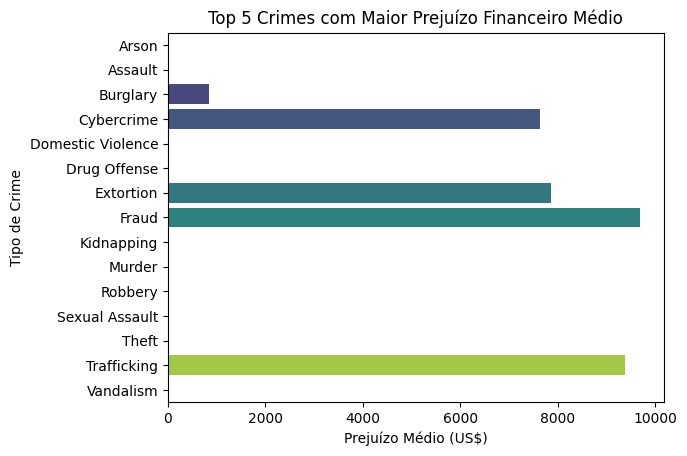

In [12]:
prejuizo = df.groupby('crime_type', observed=True)['financial_loss_usd'].mean()
prejuizo = prejuizo.sort_values(ascending=False).head(5)

sns.barplot(x=prejuizo.values, y=prejuizo.index, palette='viridis')
plt.title('Top 5 Crimes com Maior Prejuízo Financeiro Médio')
plt.xlabel('Prejuízo Médio (US$)')
plt.ylabel('Tipo de Crime')
plt.show()

|O TEMPO DE RESPOSTA MUDA A RESOLUÇÃO?|
crime_resolved
No     35.6
Yes    36.1
Name: response_time_minutes, dtype: float64


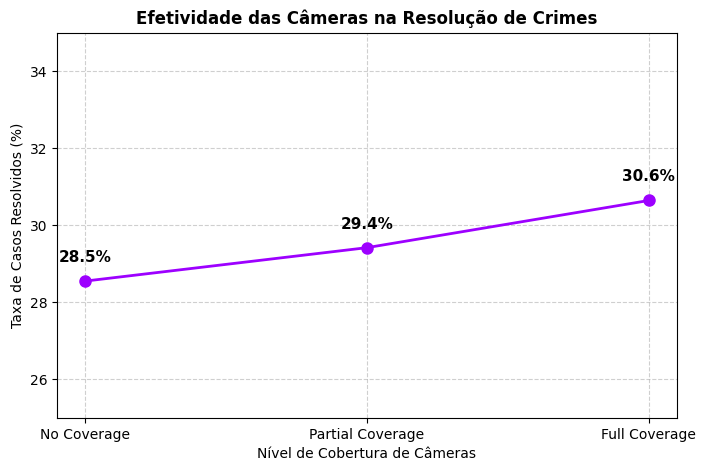

In [18]:
eficiencia_tempo = df.groupby('crime_resolved', observed=True)['response_time_minutes'].mean()

print("|O TEMPO DE RESPOSTA MUDA A RESOLUÇÃO?|")
print(eficiencia_tempo.round(1))

impacto_cameras = pd.crosstab(df['cctv_coverage'], df['crime_resolved'], normalize='index') * 100

taxa_sucesso = impacto_cameras['Yes'].sort_values()

plt.figure(figsize=(8, 5))
plt.plot(taxa_sucesso.index, taxa_sucesso.values, marker='o', color='#9D00FF', linewidth=2, markersize=8)

plt.ylim(25, 35)

plt.title('Efetividade das Câmeras na Resolução de Crimes', fontweight='bold')
plt.ylabel('Taxa de Casos Resolvidos (%)')
plt.xlabel('Nível de Cobertura de Câmeras')

for posicao, valor in enumerate(taxa_sucesso.values):
    plt.text(posicao, valor + 0.5, f'{valor:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()